# Оценка качества модели
Этот ноутбук выполняет качественную оценку обученной модели на валидационной выборке без необходимости повторного обучения.

In [1]:
import os
import random
import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import kagglehub
import kagglehub.cache
import kagglehub.handle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, log_loss
import timm
from torch.amp import autocast
from tqdm.auto import tqdm
from scipy.optimize import minimize

SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0
IMAGE_SIZE = 384
NUM_CLASSES = 120
DATASET_NAME = "dog-breed-identification"
USE_TTA = True
USE_ENSEMBLE = True
USE_KFOLD = False
KFOLD_SPLITS = 5
ENSEMBLE_MODELS = [
    {"name": "tf_efficientnetv2_s.in21k", "weights": "best_tf_efficientnetv2_s_in21k.pth"},
    {"name": "vit_base_patch16_384", "weights": "best_vit_base_patch16_384.pth"},
    {"name": "resnet50", "weights": "best_resnet50.pth"}
]
ENSEMBLE_WEIGHTS_CACHE = "ensemble_weights.npy"

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Загрузка и настройка датасета

In [2]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("API-токен Kaggle не найден.")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
TRAIN_DIR = DATA_DIR / "train"
LABELS_CSV = DATA_DIR / "labels.csv"

## 2. Подготовка валидационной выборки

In [3]:
df = pd.read_csv(LABELS_CSV)
breeds = sorted(df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for i, b in enumerate(breeds)}
df["label"] = df["breed"].map(breed_to_idx)

if USE_KFOLD:
    skf = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=SEED)
    folds = list(skf.split(df["id"], df["label"]))
    _, val_idx = folds[0]
    val_df = df.iloc[val_idx].reset_index(drop=True)
    print(f"KFold включен: {KFOLD_SPLITS} фолдов. Используем фолд 1 для базовой валидации.")
else:
    from sklearn.model_selection import train_test_split
    _, val_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df["label"],
        random_state=SEED
    )

print(f"Размер валидационной выборки: {val_df.shape[0]}")

Размер валидационной выборки: 2045


## 3. Проверка распределения классов

In [4]:
val_counts = val_df["breed"].value_counts()
print(f"Минимум изображений на породу в Validation Set: {val_counts.min()}")
print(f"Максимум изображений на породу в Validation Set: {val_counts.max()}")

Минимум изображений на породу в Validation Set: 13
Максимум изображений на породу в Validation Set: 25


## 4. Создание датасета и загрузчика

In [5]:
class DogDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.ids = df["id"].values
        self.labels = df["label"].values if "label" in df.columns else None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = f"{self.ids[idx]}.jpg"
        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        return image, self.ids[idx]

val_transforms = transforms.Compose([
    transforms.Resize((int(IMAGE_SIZE * 256 / 224), int(IMAGE_SIZE * 256 / 224))),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = DogDataset(val_df, TRAIN_DIR, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

## 5. Загрузка моделей из чекпоинтов

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def _get_fold_weights_path(weights_path, fold_id):
    stem, ext = os.path.splitext(weights_path)
    return f"{stem}_fold{fold_id}{ext}"

def load_model_with_weights(model_name, weights_path, device):
    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model

def load_models_for_spec(spec):
    if USE_KFOLD:
        weight_paths = [_get_fold_weights_path(spec["weights"], fold_id) for fold_id in range(1, KFOLD_SPLITS + 1)]
    else:
        weight_paths = [spec["weights"]]
    return [load_model_with_weights(spec["name"], path, device) for path in weight_paths]

def predict_probs(models, images):
    with autocast("cuda"):
        probs_list = []
        for model in models:
            outputs = model(images)
            if USE_TTA:
                outputs_flipped = model(torch.flip(images, dims=[3]))
                probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
            else:
                probs = torch.softmax(outputs, dim=1)
            probs_list.append(probs)
        probs_avg = torch.stack(probs_list, dim=0).mean(dim=0)
    return probs_avg

def optimize_ensemble_weights(model_specs, val_loader):
    if os.path.exists(ENSEMBLE_WEIGHTS_CACHE):
        return np.load(ENSEMBLE_WEIGHTS_CACHE)
    all_probs_list = []
    all_labels = []
    if USE_KFOLD:
        for fold_id, (_, val_idx) in enumerate(folds, start=1):
            val_df_fold = df.iloc[val_idx].reset_index(drop=True)
            val_dataset_fold = DogDataset(val_df_fold, TRAIN_DIR, transform=val_transforms)
            val_loader_fold = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
            models_per_spec = [[load_model_with_weights(spec["name"], _get_fold_weights_path(spec["weights"], fold_id), device)] for spec in model_specs]
            with torch.no_grad():
                for images, labels in val_loader_fold:
                    images = images.to(device)
                    batch_probs = []
                    for models in models_per_spec:
                        probs = predict_probs(models, images)
                        batch_probs.append(probs.cpu().numpy())
                    all_probs_list.append(np.stack(batch_probs, axis=1))
                    all_labels.extend(labels.cpu().numpy())
    else:
        models_per_spec = [load_models_for_spec(spec) for spec in model_specs]
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                batch_probs = []
                for models in models_per_spec:
                    probs = predict_probs(models, images)
                    batch_probs.append(probs.cpu().numpy())
                all_probs_list.append(np.stack(batch_probs, axis=1))
                all_labels.extend(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs_list, axis=0)
    all_labels = np.array(all_labels)
    def loss(weights_log):
        weights = np.exp(weights_log) / np.sum(np.exp(weights_log))
        weighted_probs = np.tensordot(all_probs, weights, axes=([1], [0]))
        return log_loss(all_labels, weighted_probs, labels=np.arange(NUM_CLASSES))
    init_weights = np.zeros(len(model_specs))
    res = minimize(loss, init_weights, method='L-BFGS-B')
    best_weights = np.exp(res.x) / np.sum(np.exp(res.x))
    np.save(ENSEMBLE_WEIGHTS_CACHE, best_weights)
    print(f"Оптимальные веса ансамбля: {best_weights}")
    return best_weights

Device: cuda


## 6. Получение предсказаний и измерение Latency

In [7]:
if USE_ENSEMBLE:
    models_per_spec = [load_models_for_spec(spec) for spec in ENSEMBLE_MODELS]
    weights = optimize_ensemble_weights(ENSEMBLE_MODELS, val_loader)

    all_probs = []
    all_labels = []
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Оценка на валидационной выборке"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            start_time = time.perf_counter()
            probs_sum = None
            for w, models in zip(weights, models_per_spec):
                probs = predict_probs(models, images)
                probs_sum = probs * w if probs_sum is None else probs_sum + probs * w
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            end_time = time.perf_counter()

            inference_times.append(end_time - start_time)
            all_probs.append(probs_sum.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.argmax(all_probs, axis=1)
else:
    MODEL_NAME = "vit_base_patch16_384"
    MODEL_TAG = MODEL_NAME.replace("/", "_").replace(".", "_")
    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(torch.load(f"best_{MODEL_TAG}.pth", map_location=device))
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Оценка на валидационной выборке"):
            images = images.to(device, non_blocking=True)

            start_time = time.perf_counter()
            with autocast("cuda"):
                outputs = model(images)
                if USE_TTA:
                    outputs_flipped = model(torch.flip(images, dims=[3]))
                    probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
                else:
                    probs = torch.softmax(outputs, dim=1)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            end_time = time.perf_counter()

            inference_times.append(end_time - start_time)
            _, preds = torch.max(probs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

avg_batch_time = np.mean(inference_times)
avg_image_time = avg_batch_time / BATCH_SIZE
throughput = 1.0 / avg_image_time

print(f"Average Batch Inference Latency: {avg_batch_time * 1000:.2f} ms")
print(f"Average Image Inference Latency: {avg_image_time * 1000:.2f} ms")
print(f"Throughput: {throughput:.2f} images/second")

model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Оценка на валидационной выборке:   0%|          | 0/128 [00:00<?, ?it/s]

Average Batch Inference Latency: 389.71 ms
Average Image Inference Latency: 24.36 ms
Throughput: 41.06 images/second


## 7. Расчет метрик качества

In [8]:
val_acc = np.mean(all_preds == all_labels)
val_logloss = log_loss(all_labels, all_probs, labels=np.arange(NUM_CLASSES))

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Log Loss: {val_logloss:.4f}")

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=breeds,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
breed_metrics = report_df.iloc[:-3].copy()

top_10_easy = breed_metrics.sort_values(by="f1-score", ascending=False).head(10)
print("Топ-10 пород с наивысшим F1-Score:")
display(top_10_easy[["precision", "recall", "f1-score"]])

top_10_hard = breed_metrics.sort_values(by="f1-score", ascending=True).head(10)
print("Топ-10 пород с наименьшим F1-Score:")
display(top_10_hard[["precision", "recall", "f1-score"]])

Validation Accuracy: 0.9501
Validation Log Loss: 0.2037
Топ-10 пород с наивысшим F1-Score:


,precision,recall,f1-score
african_hunting_dog,1.0,1.0,1.0
bloodhound,1.0,1.0,1.0
bedlington_terrier,1.0,1.0,1.0
briard,1.0,1.0,1.0
blenheim_spaniel,1.0,1.0,1.0
beagle,1.0,1.0,1.0
bull_mastiff,1.0,1.0,1.0
brittany_spaniel,1.0,1.0,1.0
curly-coated_retriever,1.0,1.0,1.0
doberman,1.0,1.0,1.0


Топ-10 пород с наименьшим F1-Score:


,precision,recall,f1-score
american_staffordshire_terrier,0.733333,0.733333,0.733333
australian_terrier,0.933333,0.666667,0.777778
eskimo_dog,0.833333,0.769231,0.800000
miniature_poodle,0.812500,0.812500,0.812500
norfolk_terrier,0.789474,0.882353,0.833333
staffordshire_bullterrier,0.823529,0.875000,0.848485
bouvier_des_flandres,0.875000,0.823529,0.848485
giant_schnauzer,0.857143,0.857143,0.857143
collie,1.000000,0.764706,0.866667
standard_poodle,0.875000,0.875000,0.875000


## 8. Анализ наиболее частых ошибок (Confusion Matrix Analysis)

In [9]:
confusion_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    confusion_matrix[t, p] += 1

confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and confusion_matrix[i, j] > 0:
            confused_pairs.append((idx_to_breed[i], idx_to_breed[j], confusion_matrix[i, j]))

confused_pairs = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

confused_pairs_df = pd.DataFrame(confused_pairs[:10], columns=["Истинная порода", "Предсказанная порода", "Количество ошибок"])
print("Топ-10 наиболее часто путаемых пар пород:")
display(confused_pairs_df)

Топ-10 наиболее часто путаемых пар пород:


,Истинная порода,Предсказанная порода,Количество ошибок
0,american_staffordshire_terrier,staffordshire_bullterrier,3
1,australian_terrier,norfolk_terrier,3
2,scottish_deerhound,irish_wolfhound,3
3,australian_terrier,yorkshire_terrier,2
4,collie,shetland_sheepdog,2
5,eskimo_dog,siberian_husky,2
6,irish_wolfhound,scottish_deerhound,2
7,standard_poodle,miniature_poodle,2
8,toy_terrier,miniature_pinscher,2
9,walker_hound,english_foxhound,2


## 9. Визуализация правильных и ошибочных предсказаний

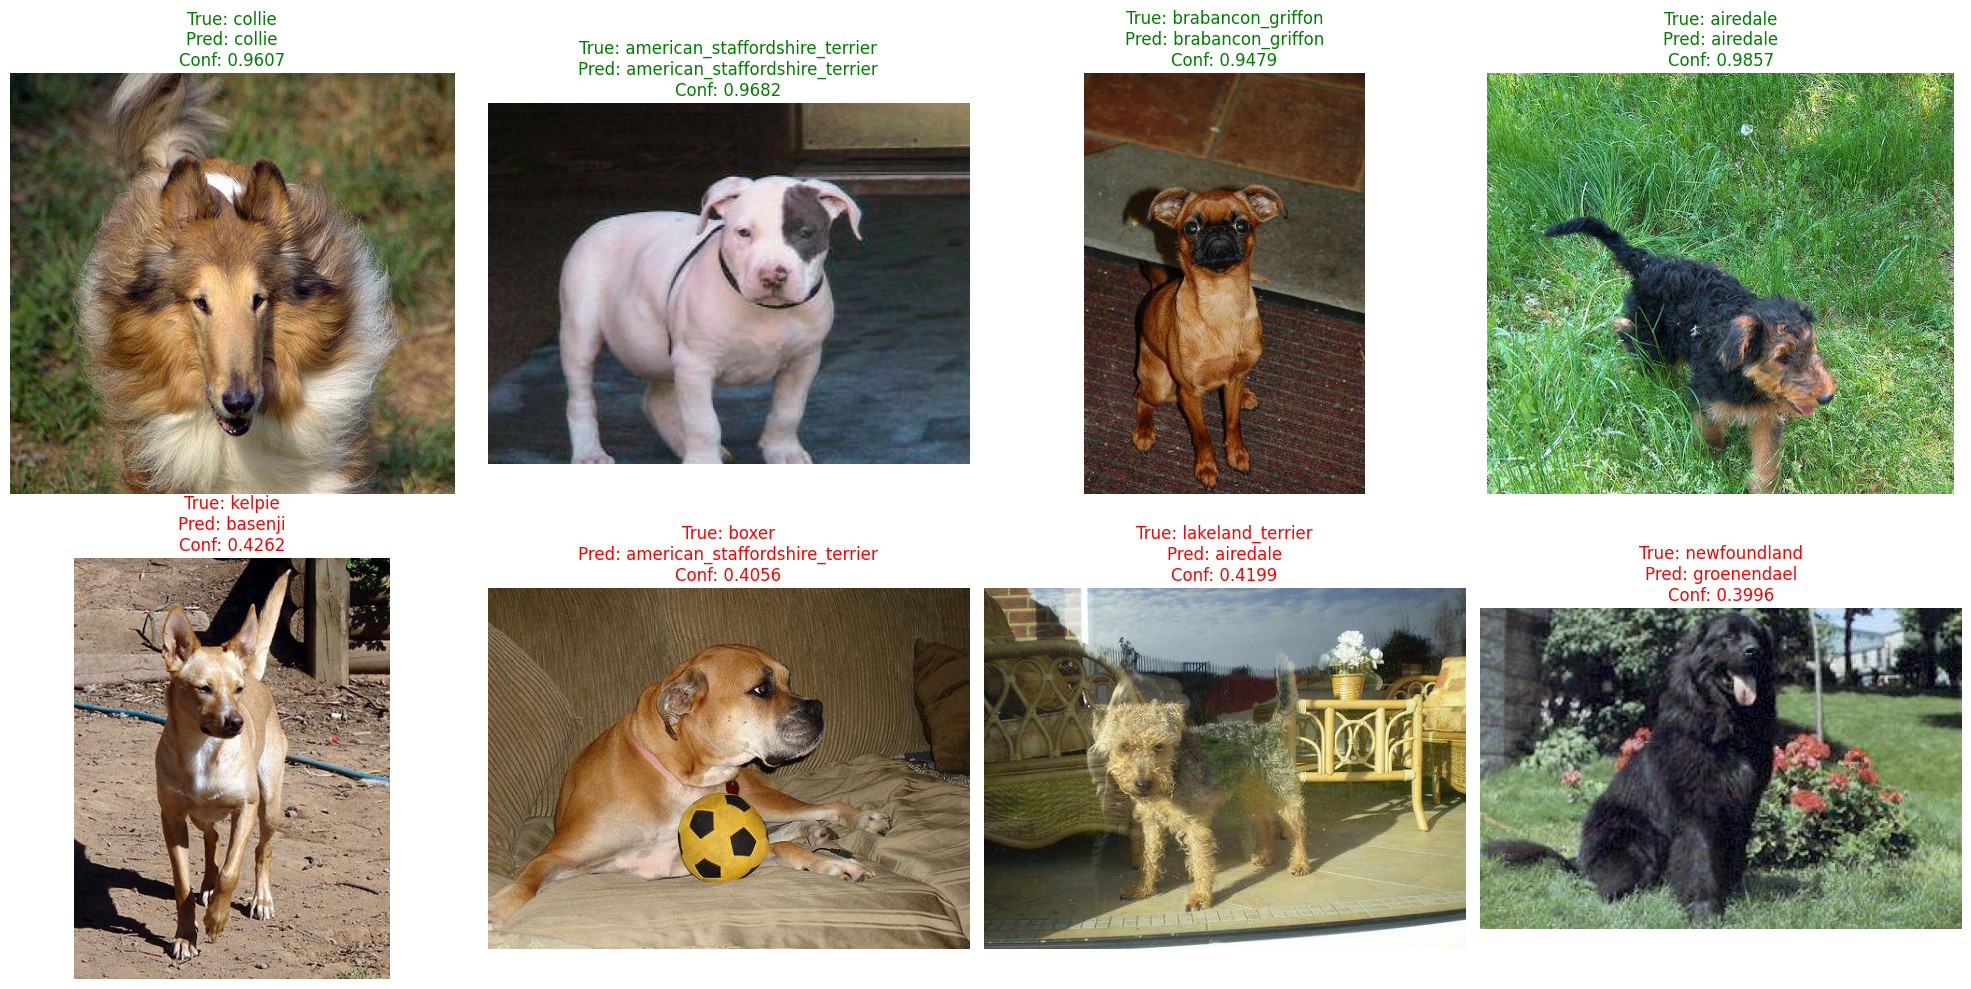

In [10]:
val_df_with_preds = val_df.copy()
val_df_with_preds["predicted_label"] = all_preds
val_df_with_preds["predicted_breed"] = val_df_with_preds["predicted_label"].map(idx_to_breed)
val_df_with_preds["confidence"] = [probs[p] for probs, p in zip(all_probs, all_preds)]
val_df_with_preds["correct"] = val_df_with_preds["label"] == val_df_with_preds["predicted_label"]

correct_samples = val_df_with_preds[val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[val_df_with_preds["correct"]])), random_state=SEED)
incorrect_samples = val_df_with_preds[~val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[~val_df_with_preds["correct"]])), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (_, row) in enumerate(correct_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[0, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="green")

for i, (_, row) in enumerate(incorrect_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[1, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="red")
plt.tight_layout()
plt.show()